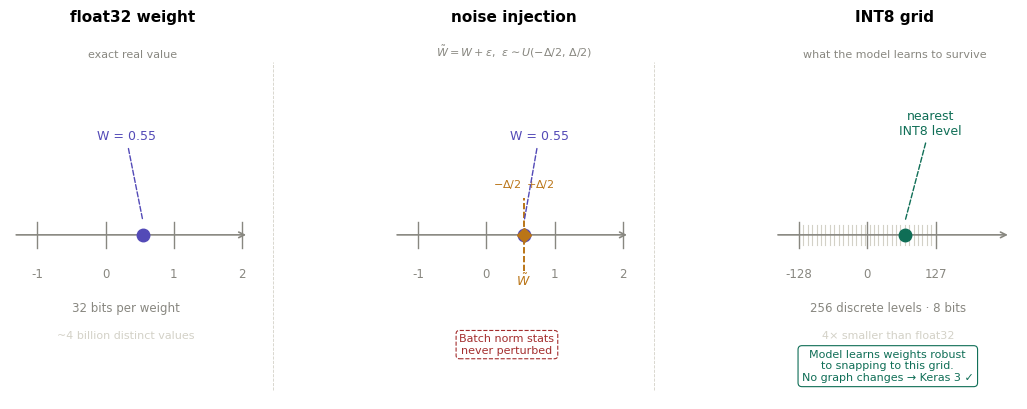

Saved to results/plots/


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patches as patches
import numpy as np

# ── Config ───────────────────────────────────────────────────────────────────
W        = 0.55
INT8_MIN, INT8_MAX = -1.0, 1.0
N_LEVELS = 256
DELTA    = (INT8_MAX - INT8_MIN) / (N_LEVELS - 1)
W_NOISY  = W - DELTA * 0.4

PURPLE = "#534AB7"
AMBER  = "#BA7517"
TEAL   = "#0F6E56"
RED    = "#A32D2D"
GRAY   = "#888780"
LGRAY  = "#D3D1C7"

# ── Canvas ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 4.5),
    gridspec_kw={"wspace": 0.55}
)
fig.patch.set_facecolor("white")

for ax in axes:
    ax.set_xlim(-1.4, 2.2)
    ax.set_ylim(-0.9, 1.0)
    ax.axis("off")

# ── Helper: draw a number line ───────────────────────────────────────────────
def draw_axis(ax, ticks, labels):
    ax.annotate(
        "", xy=(2.1, 0), xytext=(-1.35, 0),
        arrowprops=dict(arrowstyle="->", color=GRAY, lw=1.2)
    )
    for x, lbl in zip(ticks, labels):
        ax.plot([x, x], [-0.07, 0.07], color=GRAY, lw=1.0)
        ax.text(x, -0.18, lbl, ha="center", va="top",
                fontsize=8.5, color=GRAY)

# ── Panel titles ─────────────────────────────────────────────────────────────
panel_titles = [
    ("float32 weight", "exact real value"),
    ("noise injection",
     r"$\tilde{W} = W + \varepsilon$,  "
     r"$\varepsilon \sim U(-\Delta/2,\, \Delta/2)$"),
    ("INT8 grid", "what the model learns to survive"),
]
for ax, (title, subtitle) in zip(axes, panel_titles):
    ax.text(0.5, 1.08, title, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.text(0.5, 0.98, subtitle, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=8, color=GRAY)

# ════════════════════════════════════════════════════════════════════════════
# PANEL 1 — float32 number line
# ════════════════════════════════════════════════════════════════════════════
ax1 = axes[0]
draw_axis(ax1, [-1, 0, 1, 2], ["-1", "0", "1", "2"])

ax1.plot(W, 0, "o", color=PURPLE, ms=9, zorder=5)
ax1.annotate(
    f"W = {W}",
    xy=(W, 0.07),
    xytext=(W - 0.25, 0.52),
    ha="center", fontsize=9, color=PURPLE,
    arrowprops=dict(arrowstyle="-", color=PURPLE,
                    linestyle="dashed", lw=1.0)
)

ax1.text(0.3, -0.42, "32 bits per weight",
         ha="center", fontsize=8.5, color=GRAY)
ax1.text(0.3, -0.57, "~4 billion distinct values",
         ha="center", fontsize=8, color=LGRAY)

# ════════════════════════════════════════════════════════════════════════════
# PANEL 2 — noise band  (FIX: Rectangle patch in data coordinates)
# ════════════════════════════════════════════════════════════════════════════
ax2 = axes[1]
draw_axis(ax2, [-1, 0, 1, 2], ["-1", "0", "1", "2"])

band_lo  = W - DELTA / 2
band_hi  = W + DELTA / 2
band_h   = 0.28          # height of shaded rectangle in data units
band_bot = -band_h / 2   # centre the band on y=0

# shaded rectangle — drawn in data coordinates, no ymin/ymax fraction
rect = patches.FancyBboxPatch(
    (band_lo, band_bot),
    band_hi - band_lo, band_h,
    boxstyle="square,pad=0",
    linewidth=0,
    facecolor=AMBER,
    alpha=0.30,
    zorder=2
)
ax2.add_patch(rect)

# dashed vertical edges of band
ax2.plot([band_lo, band_lo], [-0.20, 0.20],
         color=AMBER, lw=1.2, linestyle="--", zorder=3)
ax2.plot([band_hi, band_hi], [-0.20, 0.20],
         color=AMBER, lw=1.2, linestyle="--", zorder=3)

# bracket labels
ax2.text(band_lo - 0.03, 0.26, r"$-\Delta/2$",
         ha="right", fontsize=8, color=AMBER)
ax2.text(band_hi + 0.03, 0.26, r"$+\Delta/2$",
         ha="left", fontsize=8, color=AMBER)

# original weight dot + annotation
ax2.plot(W, 0, "o", color=PURPLE, ms=9, zorder=5)
ax2.annotate(
    f"W = {W}",
    xy=(W, 0.07),
    xytext=(W + 0.22, 0.52),
    ha="center", fontsize=9, color=PURPLE,
    arrowprops=dict(arrowstyle="-", color=PURPLE,
                    linestyle="dashed", lw=1.0)
)

# perturbed sample dot
ax2.plot(W_NOISY, 0, "D", color=AMBER, ms=7, zorder=6)
ax2.text(W_NOISY, -0.28, r"$\tilde{W}$",
         ha="center", fontsize=9, color=AMBER)

# BN note
bbox_red = dict(boxstyle="round,pad=0.3", fc="white",
                ec=RED, lw=0.8, linestyle="dashed")
ax2.text(0.3, -0.65,
         "Batch norm stats\nnever perturbed",
         ha="center", fontsize=8, color=RED,
         bbox=bbox_red)

# ════════════════════════════════════════════════════════════════════════════
# PANEL 3 — INT8 discrete grid
# ════════════════════════════════════════════════════════════════════════════
ax3 = axes[2]
draw_axis(ax3, [-1, 0, 1], ["-128", "0", "127"])

# INT8 grid ticks
n_shown = 32
xs_grid = np.linspace(INT8_MIN, INT8_MAX, n_shown)
for x in xs_grid:
    ax3.plot([x, x], [-0.055, 0.055], color=LGRAY, lw=0.8, zorder=1)

# nearest grid point
nearest = round(W / DELTA) * DELTA
ax3.plot(nearest, 0, "o", color=TEAL, ms=9, zorder=5)
ax3.annotate(
    "nearest\nINT8 level",
    xy=(nearest, 0.07),
    xytext=(nearest + 0.38, 0.55),
    ha="center", fontsize=9, color=TEAL,
    arrowprops=dict(arrowstyle="-", color=TEAL,
                    linestyle="dashed", lw=1.0)
)

ax3.text(0.3, -0.42, "256 discrete levels · 8 bits",
         ha="center", fontsize=8.5, color=GRAY)
ax3.text(0.3, -0.57, "4× smaller than float32",
         ha="center", fontsize=8, color=LGRAY)

bbox_teal = dict(boxstyle="round,pad=0.35", fc="white",
                 ec=TEAL, lw=0.8)
ax3.text(0.3, -0.80,
         "Model learns weights robust\n"
         "to snapping to this grid.\n"
         "No graph changes → Keras 3 ✓",
         ha="center", fontsize=8, color=TEAL,
         bbox=bbox_teal)

# ── Vertical dividers ────────────────────────────────────────────────────────
for ax in [axes[0], axes[1]]:
    ax.plot([2.45, 2.45], [-0.85, 0.95],
            color=LGRAY, lw=0.6, linestyle="--",
            clip_on=False, transform=ax.transData)

# ── Save ─────────────────────────────────────────────────────────────────────
plt.savefig("results/plots/qat_noise_diagram.png",
            dpi=200, bbox_inches="tight", facecolor="white")
plt.savefig("results/plots/qat_noise_diagram.pdf",
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved to results/plots/")